<a href="https://colab.research.google.com/github/muvakimicah/big-brother/blob/main/Census_(Cleaning_Eval).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing my dataset

In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
census_income = fetch_ucirepo(id=20)

# data (as pandas dataframes)
X = census_income.data.features
y = census_income.data.targets

# metadata
print(census_income.metadata)

# variable information
print(census_income.variables)

Replacing missing values for categorical features with "missing"

In [ ]:
#workclass
X["workclass"] = X["workclass"].replace("?","Missing")
print(X["workclass"].value_counts())

#occupation
X["occupation"] = X["occupation"].fillna("Missing")
X["occupation"] = X["occupation"].replace("?","Missing")
print(X["occupation"].value_counts())

#native-country
X["native-country"].fillna("Missing")
X["native-country"] = X["native-country"].replace("?","Missing")
print(X["native-country"].value_counts())

Bucketing native-country feature to make it more balanced

<Axes: xlabel='nationality'>

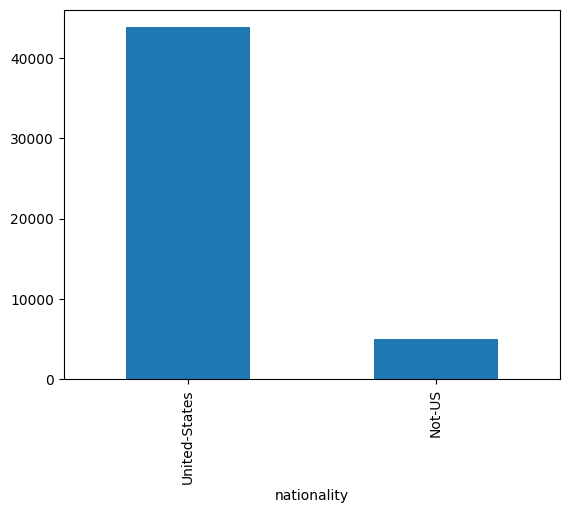

In [ ]:
import pandas as pd
import numpy as np

X["nationality"] = np.where(X["native-country"].isin(["United-States"]),
                           X["native-country"].str.title(),
                           "Not-US")

X["nationality"].value_counts().plot(kind = "bar")

Dropping features I am not using

In [ ]:
X = X.drop(['fnlwgt', 'education', 'native-country', 'relationship', 'marital-status'], axis=1)
X

,age,workclass,education-num,occupation,race,sex,capital-gain,capital-loss,hours-per-week,nationality
0,39,State-gov,13,Adm-clerical,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,13,Exec-managerial,White,Male,0,0,13,United-States
2,38,Private,9,Handlers-cleaners,White,Male,0,0,40,United-States
3,53,Private,7,Handlers-cleaners,Black,Male,0,0,40,United-States
4,28,Private,13,Prof-specialty,Black,Female,0,0,40,Not-US
...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,13,Prof-specialty,White,Female,0,0,36,United-States
48838,64,NaN,9,Missing,Black,Male,0,0,40,United-States
48839,38,Private,13,Prof-specialty,White,Male,0,0,50,United-States
48840,44,Private,13,Adm-clerical,Asian-Pac-Islander,Male,5455,0,40,United-States


One hot encode all my categorical features

In [ ]:
from sklearn.preprocessing import OneHotEncoder
#categorical_columns = census_income.variables[census_income.variables["type"] != "Integer"]
#print(categorical_columns)
#categorical_columns = X.select_dtypes(exclude=['number'])
#X[categorical_columns] = X[categorical_columns].astype('category')
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
print (categorical_columns)

#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(X[categorical_columns])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenate the one-hot encoded dataframe with the original dataframe
X = pd.concat([X, one_hot_df], axis=1)

# Drop the original categorical columns
X = X.drop(categorical_columns, axis=1)

print(X)

['workclass', 'occupation', 'race', 'sex', 'nationality']
       age  education-num  capital-gain  capital-loss  hours-per-week  \
0       39             13          2174             0              40   
1       50             13             0             0              13   
2       38              9             0             0              40   
3       53              7             0             0              40   
4       28             13             0             0              40   
...    ...            ...           ...           ...             ...   
48837   39             13             0             0              36   
48838   64              9             0             0              40   
48839   38             13             0             0              50   
48840   44             13          5455             0              40   
48841   35             13             0             0              60   

       workclass_Federal-gov  workclass_Local-gov  workclass_Miss

Model selection time! Here's my parameter grid


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

#import whatever models you want to use here
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

#pipeline
pipe = Pipeline(steps=[('classifier', 'passthrough')])

seed=42
param_grid = [
    {
     'classifier': [DecisionTreeClassifier()],
     'classifier__max_depth' : [16] ,
     'classifier__max_leaf_nodes' : [16]
    },


    {
     'classifier': [KNeighborsClassifier()],
     'classifier__leaf_size': [50],
     'classifier__p' : [1]
     },


    {
    'classifier': [LogisticRegression()],
    'classifier__solver': ['saga'],
    'classifier__penalty' : ['none']
    },
]

#from sklearn.ensemble import RandomForestClassifier

#  {
 #  'classifier': [RandomForestClassifier()],
 # 'classifier__n_estimators': [16],
 #  'classifier__bootstrap' : [16]
 #   },

Splitting the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, train_size = .75)

Now traiing the data!

In [ ]:
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, n_jobs=-1, cv=10, scoring='accuracy', error_score='raise')
grid_search.fit(X_train, y_train)
grid_search.fit(X_test, y_test)

print("tuned hyperparameters and best model:",grid_search.best_params_)
print("accuracy :",grid_search.best_score_)

results = pd.concat([pd.DataFrame(grid_search.cv_results_["params"]),pd.DataFrame(grid_search.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1)

results.sort_values('Accuracy', ascending = False).head(3)

tuned hyperparameters and best model: {'classifier': DecisionTreeClassifier(max_depth=16, max_leaf_nodes=16), 'classifier__max_depth': 16, 'classifier__max_leaf_nodes': 16}
accuracy : 0.5739904910117677


,classifier,classifier__max_depth,classifier__max_leaf_nodes,classifier__leaf_size,classifier__p,classifier__penalty,classifier__solver,Accuracy
0,"DecisionTreeClassifier(max_depth=16, max_leaf_...",16.0,16.0,NaN,NaN,NaN,NaN,0.573990
2,LogisticRegression(),NaN,NaN,NaN,NaN,none,saga,0.529685
1,KNeighborsClassifier(),NaN,NaN,50.0,1.0,NaN,NaN,0.509212



Now for testing

In [ ]:
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, n_jobs=-1, cv=10, scoring='accuracy', error_score='raise')
grid_search.fit(X_test, y_test)

print("tuned hyperparameters and best model:",grid_search.best_params_)
print("accuracy :",grid_search.best_score_)

results = pd.concat([pd.DataFrame(grid_search.cv_results_["params"]),pd.DataFrame(grid_search.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1)

results.sort_values('Accuracy', ascending = False).head(3)

tuned hyperparameters and best model: {'classifier': DecisionTreeClassifier(max_depth=16, max_leaf_nodes=16), 'classifier__max_depth': 16, 'classifier__max_leaf_nodes': 16}
accuracy : 0.5739904910117677


,classifier,classifier__max_depth,classifier__max_leaf_nodes,classifier__leaf_size,classifier__p,classifier__penalty,classifier__solver,Accuracy
0,"DecisionTreeClassifier(max_depth=16, max_leaf_...",16.0,16.0,NaN,NaN,NaN,NaN,0.573990
2,LogisticRegression(),NaN,NaN,NaN,NaN,none,saga,0.529685
1,KNeighborsClassifier(),NaN,NaN,50.0,1.0,NaN,NaN,0.509212



...and then predictions

In [ ]:
from sklearn.metrics import classification_report
y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       <=50K       0.59      0.93      0.72      6259
      <=50K.       0.93      0.07      0.13      3097
        >50K       0.47      0.52      0.49      1914
       >50K.       0.00      0.00      0.00       941

    accuracy                           0.58     12211
   macro avg       0.50      0.38      0.34     12211
weighted avg       0.61      0.58      0.48     12211



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion matrix

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

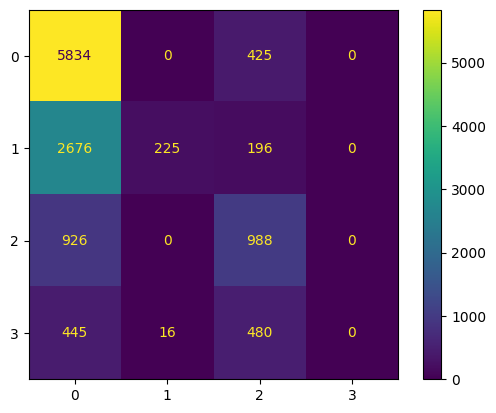

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels = labels)
cmd.plot()